In [1]:
# 1. 创建 Keras 官方存放模型的隐藏文件夹
!mkdir -p /home/ma-user/.keras/models/

# 2. 将当前目录下的文件移动/复制过去
!cp vgg19_weights_tf_dim_ordering_tf_kernels_notop.h5 /home/ma-user/.keras/models/

# 3. 检查是否移动成功
!ls /home/ma-user/.keras/models/

vgg19_weights_tf_dim_ordering_tf_kernels_notop.h5


✅ 已成功开启显存自适应增长
Found 292 images belonging to 8 classes.
Found 73 images belonging to 8 classes.
  ...
    to  
  ['...']
  ...
    to  
  ['...']
Train for 146 steps, validate for 37 steps
Epoch 1/200
146/146 [==============================] - 9s 61ms/step - loss: 9.3939 - accuracy: 0.1712 - val_loss: 2.0482 - val_accuracy: 0.2192
Epoch 2/200
146/146 [==============================] - 4s 30ms/step - loss: 2.5693 - accuracy: 0.1781 - val_loss: 1.9157 - val_accuracy: 0.2877
Epoch 3/200
146/146 [==============================] - 4s 30ms/step - loss: 2.1851 - accuracy: 0.2158 - val_loss: 1.8244 - val_accuracy: 0.3562
Epoch 4/200
146/146 [==============================] - 4s 30ms/step - loss: 1.9862 - accuracy: 0.2568 - val_loss: 1.6726 - val_accuracy: 0.4795
Epoch 5/200
146/146 [==============================] - 4s 30ms/step - loss: 1.7823 - accuracy: 0.3630 - val_loss: 1.5426 - val_accuracy: 0.4521
Epoch 6/200
146/146 [==============================] - 4s 29ms/step - loss: 1.6351 - accura

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei


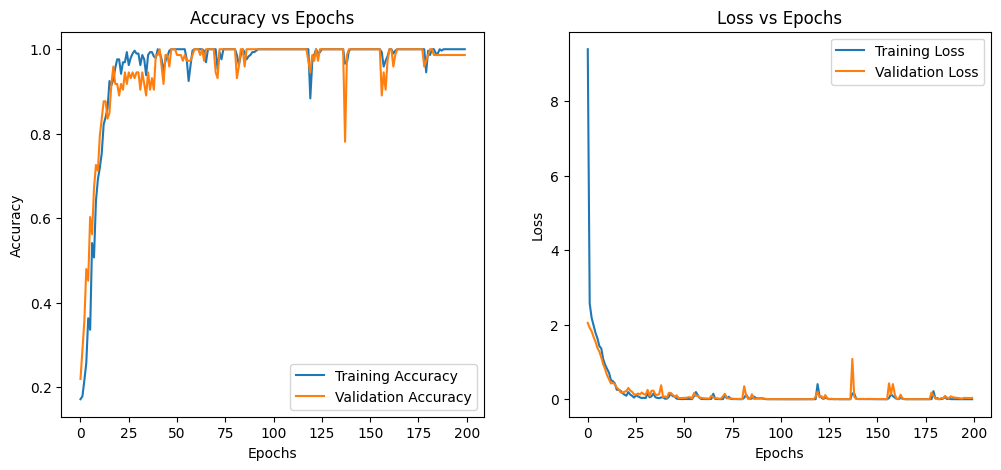

📊 训练曲线图已保存至: training_results/plots/training_metrics.png
💾 H5格式模型已保存至: training_results/models/VGG19_CBAM_model.h5


2026-03-23 02:36:42.566981: W tensorflow/python/util/util.cc:319] Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.


Instructions for updating:
If using Keras pass *_constraint arguments to layers.
INFO:tensorflow:Assets written to: training_results/models/VGG19_CBAM_model_tf/assets
💾 TF格式模型已保存至: training_results/models/VGG19_CBAM_model_tf
📝 训练历史数据已保存至: training_results/training_history.npy


In [3]:
import os
import tensorflow as tf

# 配置 GPU 显存自适应增长
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ 已成功开启显存自适应增长")
    except RuntimeError as e:
        print(f"❌ 显存设置失败: {e}")
       
    
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.applications import VGG19
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# 设置中文字体（防止中文乱码）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 创建保存目录
save_dir = 'training_results'
model_dir = os.path.join(save_dir, 'models')
plot_dir = os.path.join(save_dir, 'plots')
os.makedirs(model_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)

# 1. 定义CBAM模块
class CBAM(tf.keras.layers.Layer):
    def __init__(self, ratio=8,  ** kwargs):
        super(CBAM, self).__init__(**kwargs)
        self.ratio = ratio
        self.channel_axis = -1

    def build(self, input_shape):
        self.channel_avg_pool = layers.GlobalAveragePooling2D()
        self.channel_max_pool = layers.GlobalMaxPooling2D()
        channel_dim = input_shape[self.channel_axis]
        self.shared_mlp = tf.keras.Sequential([
            layers.Dense(channel_dim // self.ratio, activation='relu'),
            layers.Dense(channel_dim)
        ])
        self.conv2d = layers.Conv2D(1, (7, 7), padding='same', activation='sigmoid')
        super(CBAM, self).build(input_shape)

    def call(self, inputs):
        # 通道注意力
        avg_pool = self.channel_avg_pool(inputs)
        max_pool = self.channel_max_pool(inputs)
        avg_pool = layers.Reshape((1, 1, avg_pool.shape[-1]))(avg_pool)
        max_pool = layers.Reshape((1, 1, max_pool.shape[-1]))(max_pool)
        channel_attention = tf.nn.sigmoid(self.shared_mlp(avg_pool) + self.shared_mlp(max_pool))
        channel_refined = inputs * channel_attention

        # 空间注意力
        avg_pool = tf.reduce_mean(channel_refined, axis=self.channel_axis, keepdims=True)
        max_pool = tf.reduce_max(channel_refined, axis=self.channel_axis, keepdims=True)
        concat = layers.Concatenate()([avg_pool, max_pool])
        spatial_attention = self.conv2d(concat)
        return channel_refined * spatial_attention

    def get_config(self):
        config = super(CBAM, self).get_config()
        config.update({"ratio": self.ratio})
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

# 2. 构建带CBAM的VGG19模型
def build_vgg19_with_cbam(num_classes=8):
    base_model = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    for layer in base_model.layers:
        layer.trainable = False

    # 获取各卷积块输出并插入CBAM
    cbam_outputs = []
    for block_num in [1, 2, 3, 4, 5]:
        conv_num = 2 if block_num < 3 else 4
        layer_name = f'block{block_num}_conv{conv_num}'
        x = base_model.get_layer(layer_name).output
        x = CBAM(ratio=8)(x)
        cbam_outputs.append(x)

    # 统一调整所有特征图到最小尺寸(7x7)
    target_size = 7
    adjusted_features = []
    for feature in cbam_outputs:
        current_size = feature.shape[1]
        downsample_factor = current_size // target_size
        x = feature
        for _ in range(int(tf.math.log(float(downsample_factor)) / tf.math.log(2.0))):
            x = layers.MaxPooling2D(2)(x)
        adjusted_features.append(x)

    # 特征融合
    fused_feature = layers.Concatenate()(adjusted_features)
    x = layers.GlobalAveragePooling2D()(fused_feature)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs=base_model.input, outputs=outputs)

# 3. 训练配置
with tf.device('/GPU:0'):
    model = build_vgg19_with_cbam(num_classes=8)
    model.compile(optimizer=Adam(0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

    train_datagen = ImageDataGenerator(
        rescale=1. / 255,
        #rotation_range=40,
        #width_shift_range=0.2,
        #height_shift_range=0.2,
        #shear_range=0.2,
        #zoom_range=0.2,
        #horizontal_flip=True,
        #fill_mode='nearest',
        #validation_split=0.2 # 使用20%的数据作为验证集
    )

    train_generator = train_datagen.flow_from_directory(
        'train_test_no',
        target_size=(224, 224),
        batch_size=2,
        class_mode='categorical',
        #subset='training'
    )

    # 创建验证数据的生成器（通常不进行数据增强）
    val_datagen = ImageDataGenerator(rescale=1. / 255)

    validation_generator = val_datagen.flow_from_directory(
        'test_0.2',
        target_size=(224, 224),
        batch_size=2,
        class_mode='categorical',
        #subset='validation'
    )

    history = model.fit(
        train_generator,
        steps_per_epoch=len(train_generator), # steps_per_epoch=len(train_generator),
        epochs=200,
        validation_data=validation_generator,
        validation_steps=len(validation_generator)
    )

    # 可视化训练过程（英文标题）
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy vs Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss vs Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    # 保存可视化图像（英文文件名）
    plot_filename = os.path.join(plot_dir, 'training_metrics.png')
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"📊 训练曲线图已保存至: {plot_filename}")

    # 保存模型
    # 方式1: 保存为H5格式
    h5_model_path = os.path.join(model_dir, 'VGG19_CBAM_model.h5')
    model.save(h5_model_path)
    print(f"💾 H5格式模型已保存至: {h5_model_path}")
    
    # 方式2: 保存为TF格式（推荐）
    tf_model_path = os.path.join(model_dir, 'VGG19_CBAM_model_tf')
    model.save(tf_model_path, save_format='tf')
    print(f"💾 TF格式模型已保存至: {tf_model_path}")
    
    # 可选：保存训练历史数据
    history_path = os.path.join(save_dir, 'training_history.npy')
    np.save(history_path, history.history)
    print(f"📝 训练历史数据已保存至: {history_path}")

Loading model from VGG19_CBAM_final_model.h5...
❌ Error loading model: SavedModel file does not exist at: VGG19_CBAM_final_model.h5/{saved_model.pbtxt|saved_model.pb}
Found 73 images belonging to 8 classes.
Processing 73 validation images...
✅ Displayed results saved as: labeled_validation_results.png


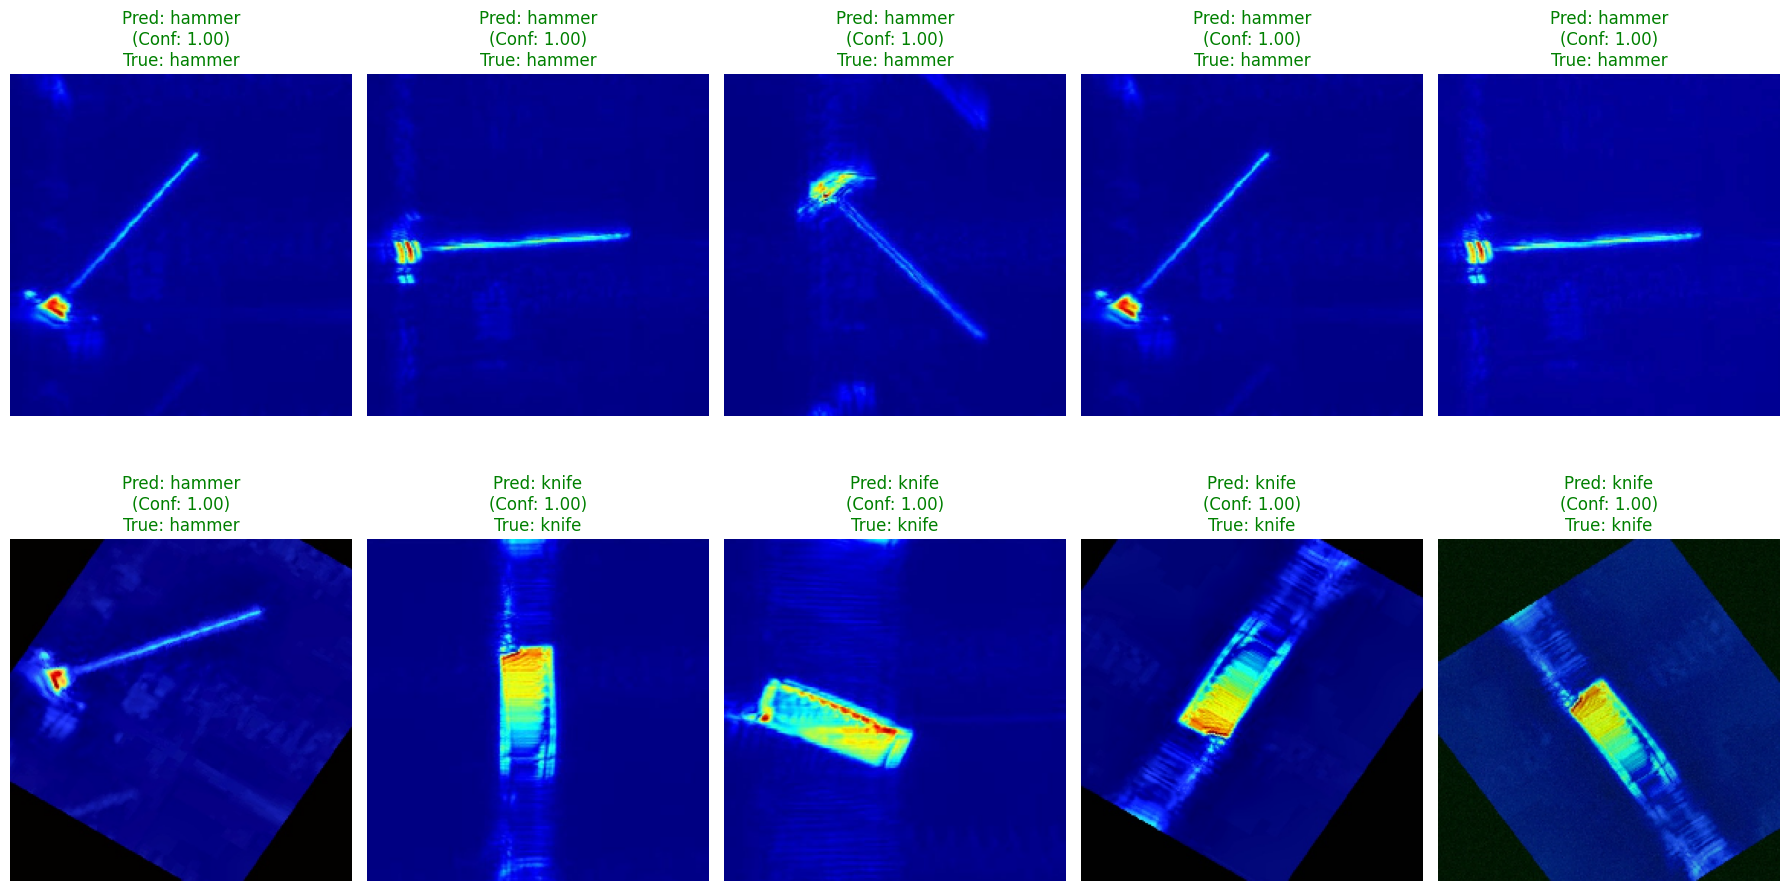

In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import custom_object_scope
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- 1. 配置路径与参数 ---
model_path = 'VGG19_CBAM_final_model.h5' # 你保存的模型路径
test_dir = 'test_0.2' # 验证集目录
target_size = (224, 224) # 与训练时保持一致

# 定义类别映射（重要：Keras 是按字母顺序读取文件夹的）
# 确保这里的顺序和你 train_generator.class_indices 打印出来的一致
class_names = [
    'hammer', 'knife', 'pistol', 'plier', 
    'rifle', 'snips', 'stiletto', 'wrench'
]

# --- 2. 加载自定义模型 (使用 custom_object_scope) ---
print(f"Loading model from {model_path}...")
try:
    with custom_object_scope({'CBAM': CBAM}):
        model = load_model(model_path)
    print("✅ Model loaded successfully.")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    # 如果报错，请检查本单元格之前是否定义了 CBAM 类

# --- 3. 准备验证集数据生成器 ---
# 注意：batch_size 设为 1，方便我们一张张处理
val_datagen = ImageDataGenerator(rescale=1. / 255)
val_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=target_size,
    batch_size=1, # 必须为 1
    class_mode='categorical',
    shuffle=False # 必须为 False，保持顺序一致
)

# 获取总图片数
num_samples = len(val_generator)
print(f"Processing {num_samples} validation images...")

# --- 4. 遍历图片进行打标与显示 ---
# 我们选取前 10 张图片作为示例展示
num_to_show = 10
displayed_count = 0

plt.figure(figsize=(18, 10))

for i in range(num_samples):
    # 1. 获取一张图片及其真实标签
    X, y_true = val_generator.next()
    
    # 2. 模型预测
    preds = model.predict(X)
    
    # 3. 解析预测结果
    pred_idx = np.argmax(preds) # 预测得分最高的索引
    true_idx = np.argmax(y_true) # 真实索引
    
    pred_label = class_names[pred_idx]
    true_label = class_names[true_idx]
    confidence = preds[0][pred_idx] # 预测置信度
    
    # 4. 可视化
    if displayed_count < num_to_show:
        displayed_count += 1
        
        # 将 [1, 224, 224, 3] 转回 [224, 224, 3] 并还原像素范围到 0-255
        img_show = (X[0] * 255).astype('uint8')
        
        # 准备标题
        title_text = f"Pred: {pred_label}\n(Conf: {confidence:.2f})\nTrue: {true_label}"
        
        # 确定颜色：正确为绿色，错误为红色
        color = 'green' if pred_idx == true_idx else 'red'
        
        plt.subplot(2, num_to_show//2, displayed_count)
        plt.imshow(img_show)
        plt.title(title_text, color=color, fontsize=12)
        plt.axis('off')

# 自动布局调整并保存结果图
plt.tight_layout()
plt.savefig('labeled_validation_results.png', dpi=300)
print(f"✅ Displayed results saved as: labeled_validation_results.png")
plt.show()

Classes detected: ['class_hammer', 'class_knife', 'class_pistol', 'class_plier', 'class_rifle', 'class_snips', 'class_stiletto', 'class_wrench']
❌ Still error: SavedModel file does not exist at: VGG19_CBAM_final_model.h5/{saved_model.pbtxt|saved_model.pb}
Found 73 images belonging to 8 classes.
Searching for misclassified images among 73 samples...
🚩 Found 1 errors. Displaying...


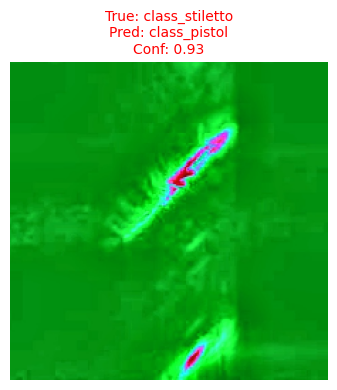

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import custom_object_scope
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- 核心修复：解决 'str' object has no attribute 'decode' ---
# 这是一个环境兼容性补丁
import h5py
if not hasattr(h5py, 'File'):
    import h5py

# --- 配置 ---
model_path = 'VGG19_CBAM_final_model.h5'
test_dir = 'test_0.2'
target_size = (224, 224)

# 类别映射（请确保顺序与文件夹字母顺序一致）
class_names = sorted(os.listdir(test_dir)) 
print(f"Classes detected: {class_names}")

# --- 加载模型 ---
try:
    with custom_object_scope({'CBAM': CBAM}):
        # compile=False 可以跳过保存时可能存在的优化器兼容性问题
        model = load_model(model_path, compile=False) 
    print("✅ Model loaded successfully (Patch Applied).")
except Exception as e:
    print(f"❌ Still error: {e}")

# --- 准备验证集 ---
val_datagen = ImageDataGenerator(rescale=1. / 255)
val_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=target_size,
    batch_size=1,
    class_mode='categorical',
    shuffle=False
)

# --- 专门寻找预测错误 (Misclassified Samples) ---
error_samples = []
num_samples = len(val_generator)

print(f"Searching for misclassified images among {num_samples} samples...")

for i in range(num_samples):
    X, y_true = val_generator.next()
    preds = model.predict(X)
    
    pred_idx = np.argmax(preds)
    true_idx = np.argmax(y_true)
    
    if pred_idx != true_idx:
        # 记录错误样本的信息
        error_samples.append({
            'image': X[0],
            'pred': class_names[pred_idx],
            'true': class_names[true_idx],
            'conf': preds[0][pred_idx],
            'filename': val_generator.filenames[i]
        })

# --- 显示错误样本 ---
if not error_samples:
    print("✨ No errors found! Accuracy is 100% on this set.")
else:
    num_errors = len(error_samples)
    print(f"🚩 Found {num_errors} errors. Displaying...")
    
    # 动态调整显示列数
    cols = min(num_errors, 5)
    rows = (num_errors // cols) + (1 if num_errors % cols != 0 else 0)
    
    plt.figure(figsize=(cols * 4, rows * 4))
    for i, err in enumerate(error_samples):
        plt.subplot(rows, cols, i + 1)
        plt.imshow((err['image'] * 255).astype('uint8'))
        title = f"True: {err['true']}\nPred: {err['pred']}\nConf: {err['conf']:.2f}"
        plt.title(title, color='red', fontsize=10)
        plt.axis('off')
    
    plt.tight_layout()
    plt.savefig('misclassified_analysis.png', dpi=300)
    plt.show()